# Préparation du dataset Walk + Évaluation avec imu-activity-classifier

## Pipeline
1. Extraire le label `walk` (id=2) du dataset 10GB
2. Adapter le format pour le classifieur UCI HAR :
   - 50 timesteps → **128 timesteps** (interpolation)
   - 3 canaux → **9 canaux** (body_acc / body_gyro=0 / total_acc)
   - Normalisation UCI HAR
3. Sauvegarder le dataset adapté
4. Télécharger le modèle TFLite depuis HuggingFace
5. Évaluer : score WALKING sur les vraies données

In [ ]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as pa
from scipy import signal as scipy_signal
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import urllib.request
from collections import Counter
import gc

print('Imports OK')

## 1. Configuration

In [2]:
# ── Chemins ────────────────────────────────────────────────────────
SOURCE_PATH = r"C:/Users/adril/Downloads/unified_dataset.parquet"
OUTPUT_PATH = r"C:/Users/adril/Downloads/walk_dataset.parquet"
MODEL_DIR   = r"C:/Users/adril/Downloads/imu_classifier"
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Paramètres ─────────────────────────────────────────────────────
WALK_LABEL_ID  = 2          # global_activity_id pour walk
FS_SOURCE      = 50         # Hz de ton dataset
FS_TARGET      = 50         # Hz UCI HAR (même fréquence, pas de rééchantillonnage)
WIN_SOURCE     = 50         # timesteps dans ton dataset (2s à 50Hz)
WIN_TARGET     = 128        # timesteps attendus par le classifieur
STRIDE         = 25         # stride pour le fenêtrage
N_CHANNELS_OUT = 9          # body_acc xyz + body_gyro xyz + total_acc xyz

# ── Normalisation UCI HAR ──────────────────────────────────────────
# Ces stats viennent du dataset UCI HAR original (valeurs publiées)
# body_acc  : mean≈0, std≈1 (déjà centré dans UCI)
# total_acc : mean≈0.99, std≈0.40 (magnitude ~1g au repos)
# On va calculer nos propres stats sur le walk extrait (plus propre)

# ── Labels du classifieur ──────────────────────────────────────────
# 0=WALKING  1=WALKING_UPSTAIRS  2=WALKING_DOWNSTAIRS
# 3=SITTING  4=STANDING          5=LAYING
CLASSIFIER_ACTIVITIES = [
    'WALKING','WALKING_UPSTAIRS','WALKING_DOWNSTAIRS',
    'SITTING','STANDING','LAYING'
]
WALKING_CLASS_IDX = 0   # index de WALKING dans le modèle

print('Configuration OK')
print(f'  Source  : {SOURCE_PATH}')
print(f'  Output  : {OUTPUT_PATH}')
print(f'  Modèle  : {MODEL_DIR}')

Configuration OK
  Source  : C:/Users/adril/Downloads/unified_dataset.parquet
  Output  : C:/Users/adril/Downloads/walk_dataset.parquet
  Modèle  : C:/Users/adril/Downloads/imu_classifier


## 2. Extraction du label Walk depuis le dataset 10GB
Lecture par chunks de 500K lignes — ne charge jamais tout en RAM.

In [3]:
pf     = pq.ParquetFile(SOURCE_PATH)
writer = None
total  = 0

print('Extraction walk en cours...')
for i, batch in enumerate(pf.iter_batches(batch_size=500_000)):
    df = batch.to_pandas()
    df_walk = df[df['global_activity_id'] == WALK_LABEL_ID].copy()

    if len(df_walk) == 0:
        continue

    table = pa.Table.from_pandas(df_walk, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PATH, table.schema, compression='snappy')
    writer.write_table(table)
    total += len(df_walk)
    print(f'  chunk {i+1} — {total:,} lignes walk écrites', end='\r')
    del df, df_walk; gc.collect()

if writer:
    writer.close()

print(f'\nTerminé : {total:,} lignes walk sauvegardées dans {OUTPUT_PATH}')

Extraction walk en cours...
  chunk 1415 — 2,953,949 lignes walk écrites
Terminé : 2,953,949 lignes walk sauvegardées dans C:/Users/adril/Downloads/walk_dataset.parquet


## 3. Fenêtrage + Adaptation format UCI HAR

### Transformations appliquées :
| Canal UCI HAR | Source | Méthode |
|---|---|---|
| body_acc xyz | acc_x/y/z | Filtre passe-haut 0.3Hz (retire gravité) |
| body_gyro xyz | — | **Zéros** (pas de gyro disponible) |
| total_acc xyz | acc_x/y/z | Signal brut (= gravité + mouvement) |

Interpolation linéaire 50 → 128 timesteps par fenêtre.

In [4]:
def highpass_filter(x, cutoff=0.3, fs=50, order=3):
    """Filtre passe-haut pour extraire body_acc (retire la composante gravité)."""
    nyq = fs / 2.0
    b, a = scipy_signal.butter(order, cutoff / nyq, btype='high')
    return scipy_signal.filtfilt(b, a, x, axis=0)

def interpolate_window(win_50, target_len=128):
    """Interpole linéairement une fenêtre (50, C) → (128, C)."""
    x_old = np.linspace(0, 1, len(win_50))
    x_new = np.linspace(0, 1, target_len)
    out   = np.zeros((target_len, win_50.shape[1]), dtype=np.float32)
    for c in range(win_50.shape[1]):
        f = interp1d(x_old, win_50[:, c], kind='linear')
        out[:, c] = f(x_new)
    return out

def build_9ch_window(acc_win):
    """
    acc_win : (50, 3) — acc_x, acc_y, acc_z brut
    Retourne : (128, 9) — body_acc(3) + body_gyro(3)=0 + total_acc(3)
    """
    # body_acc = passe-haut (retire gravité)
    body_acc  = highpass_filter(acc_win.astype(np.float64)).astype(np.float32)
    # total_acc = signal brut
    total_acc = acc_win.astype(np.float32)
    # body_gyro = zéros (pas disponible)
    body_gyro = np.zeros_like(acc_win, dtype=np.float32)

    # Concaténation : (50, 9)
    win_9ch = np.concatenate([body_acc, body_gyro, total_acc], axis=1)

    # Interpolation 50 → 128
    win_128 = interpolate_window(win_9ch, target_len=128)
    return win_128   # (128, 9)

print('Fonctions de transformation définies.')

Fonctions de transformation définies.


In [5]:
# ── Fenêtrage par session ──────────────────────────────────────────
pf       = pq.ParquetFile(OUTPUT_PATH)
X_list   = []
X_raw_list = []   # 3 axes bruts (50 pts) pour la visualisation et le VAE
total_w  = 0

print('Fenêtrage et transformation...')
for i, batch in enumerate(pf.iter_batches(batch_size=500_000)):
    df = batch.to_pandas()

    for gk, grp in df.groupby(['dataset', 'subject_id', 'session_id']):
        grp = grp.sort_values('timestamp_ns')
        acc = grp[['acc_x','acc_y','acc_z']].values.astype(np.float32)

        if len(acc) < WIN_SOURCE:
            continue

        for j in range(0, len(acc) - WIN_SOURCE + 1, STRIDE):
            win_raw = acc[j:j+WIN_SOURCE]          # (50, 3)
            win_9ch = build_9ch_window(win_raw)    # (128, 9)
            X_list.append(win_9ch)
            X_raw_list.append(win_raw)
            total_w += 1

    del df; gc.collect()
    print(f'  chunk {i+1} — {total_w:,} fenêtres', end='\r')

X_9ch = np.array(X_list,     dtype=np.float32)   # (N, 128, 9)
X_raw = np.array(X_raw_list, dtype=np.float32)   # (N, 50, 3)
del X_list, X_raw_list; gc.collect()

print(f'\nFenêtres créées : {X_9ch.shape}  (raw: {X_raw.shape})')

Fenêtrage et transformation...
  chunk 6 — 117,945 fenêtres
Fenêtres créées : (117945, 128, 9)  (raw: (117945, 50, 3))


## 4. Normalisation UCI HAR

On calcule mean/std **par canal** sur notre propre dataset walk.
C'est la même approche que UCI HAR (z-score par canal sur le train set).

In [6]:
# Normalisation z-score par canal (sur (N, 128, 9) → reshape en (N*128, 9))
N, T, C = X_9ch.shape
X_flat  = X_9ch.reshape(-1, C)   # (N*128, 9)

scaler  = StandardScaler()
X_norm_flat = scaler.fit_transform(X_flat)
X_norm  = X_norm_flat.reshape(N, T, C).astype(np.float32)   # (N, 128, 9)

print('Normalisation par canal :')
ch_names = ['body_acc_x','body_acc_y','body_acc_z',
            'gyro_x','gyro_y','gyro_z',
            'total_acc_x','total_acc_y','total_acc_z']
print(f'{"Canal":<16} {"Mean avant":>12} {"Std avant":>10} {"Mean après":>12} {"Std après":>10}')
print('-' * 64)
for c in range(C):
    m_b = scaler.mean_[c]; s_b = scaler.scale_[c]
    m_a = X_norm[:,:,c].mean(); s_a = X_norm[:,:,c].std()
    print(f'{ch_names[c]:<16} {m_b:>12.4f} {s_b:>10.4f} {m_a:>12.4f} {s_a:>10.4f}')

Normalisation par canal :
Canal              Mean avant  Std avant   Mean après  Std après
----------------------------------------------------------------
body_acc_x            -0.0026     2.8016       0.0000     1.0000
body_acc_y            -0.0019     2.8714      -0.0000     1.0000
body_acc_z             0.0036     2.0574      -0.0000     1.0000
gyro_x                 0.0000     1.0000       0.0000     0.0000
gyro_y                 0.0000     1.0000       0.0000     0.0000
gyro_z                 0.0000     1.0000       0.0000     0.0000
total_acc_x           -2.3590     6.3352       0.0000     1.0000
total_acc_y            1.4910     7.5021      -0.0000     1.0000
total_acc_z            0.7225     3.6079      -0.0000     1.0000


## 5. Visualisation — quelques fenêtres après transformation

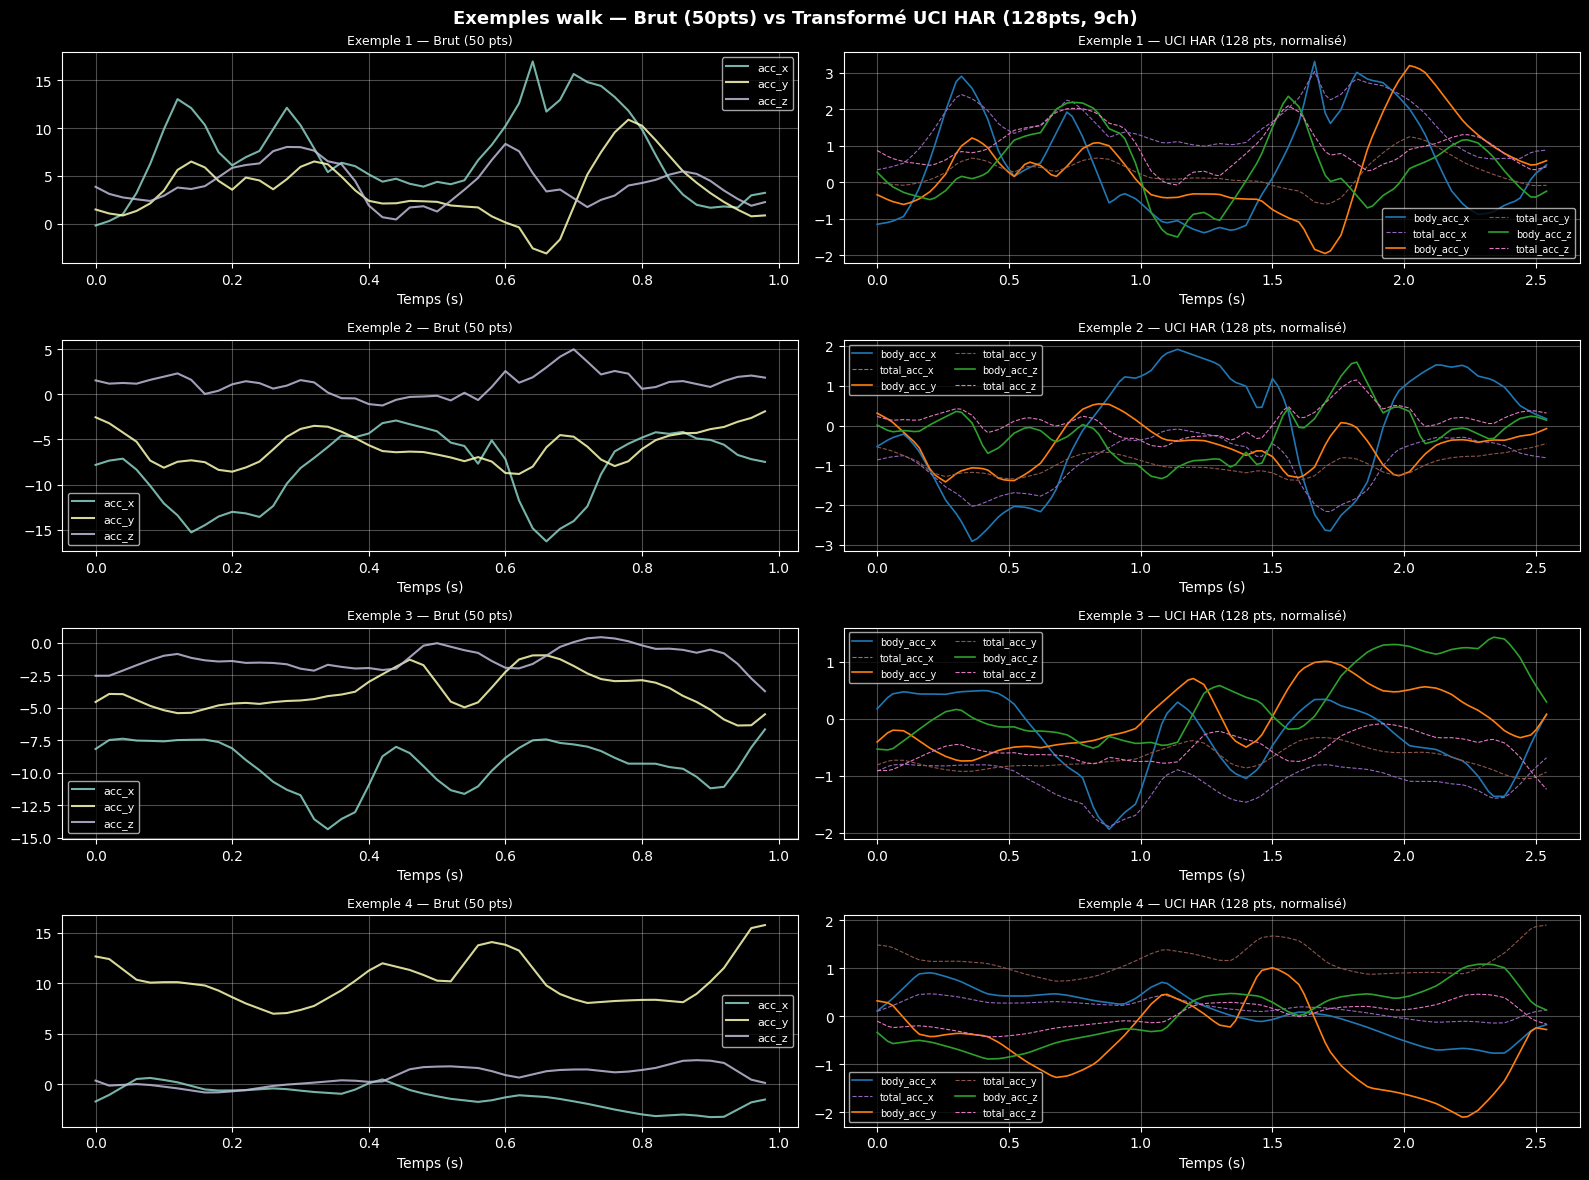

In [7]:
N_SHOW = 4
idxs   = np.random.choice(len(X_norm), N_SHOW, replace=False)
t_128  = np.arange(128) / FS_TARGET
t_50   = np.arange(50)  / FS_SOURCE

fig, axes = plt.subplots(N_SHOW, 2, figsize=(16, N_SHOW*3))
fig.suptitle('Exemples walk — Brut (50pts) vs Transformé UCI HAR (128pts, 9ch)',
             fontsize=13, fontweight='bold')

for row, idx in enumerate(idxs):
    # Colonne gauche : signal brut 3 axes
    ax = axes[row, 0]
    for j, lbl in enumerate(['acc_x','acc_y','acc_z']):
        ax.plot(t_50, X_raw[idx,:,j], label=lbl, alpha=0.85)
    ax.set_title(f'Exemple {row+1} — Brut (50 pts)', fontsize=9)
    ax.set_xlabel('Temps (s)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Colonne droite : signal normalisé 9 canaux (128 pts)
    ax = axes[row, 1]
    colors_ba = ['#1f77b4','#ff7f0e','#2ca02c']
    colors_ta = ['#9467bd','#8c564b','#e377c2']
    for j in range(3):
        ax.plot(t_128, X_norm[idx,:,j],   color=colors_ba[j],
                label=f'body_acc_{["x","y","z"][j]}', lw=1.2)
        ax.plot(t_128, X_norm[idx,:,6+j], color=colors_ta[j],
                label=f'total_acc_{["x","y","z"][j]}', lw=0.8, linestyle='--')
    ax.set_title(f'Exemple {row+1} — UCI HAR (128 pts, normalisé)', fontsize=9)
    ax.set_xlabel('Temps (s)'); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Téléchargement du modèle TFLite depuis HuggingFace

On télécharge `imu_pruned_int8.tflite` (113KB, le plus performant).

In [8]:
MODEL_URL  = "https://huggingface.co/raj5517/imu-activity-classifier/resolve/main/imu_pruned_int8.tflite"
MODEL_PATH = os.path.join(MODEL_DIR, "imu_pruned_int8.tflite")

if not os.path.exists(MODEL_PATH):
    print(f'Téléchargement du modèle...')
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    size_kb = os.path.getsize(MODEL_PATH) / 1024
    print(f'  Modèle téléchargé : {MODEL_PATH}  ({size_kb:.1f} KB)')
else:
    print(f'Modèle déjà présent : {MODEL_PATH}')

# Chargement et inspection
import tensorflow as tf
print(f'TensorFlow : {tf.__version__}')

interpreter = tf.lite.Interpreter(MODEL_PATH)
interpreter.allocate_tensors()
input_det  = interpreter.get_input_details()
output_det = interpreter.get_output_details()

print(f"\nInput  : shape={input_det[0]['shape']}   dtype={input_det[0]['dtype']}")
print(f"Output : shape={output_det[0]['shape']}  dtype={output_det[0]['dtype']}")
print(f"\nClasses : {CLASSIFIER_ACTIVITIES}")

Téléchargement du modèle...
  Modèle téléchargé : C:/Users/adril/Downloads/imu_classifier\imu_pruned_int8.tflite  (113.3 KB)
TensorFlow : 2.21.0

Input  : shape=[  1 128   9]   dtype=<class 'numpy.float32'>
Output : shape=[1 6]  dtype=<class 'numpy.float32'>

Classes : ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


D:\IMDS\MALMO\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 7. Évaluation sur les vraies données Walk

On passe toutes les fenêtres normalisées dans le classifieur.
**Résultat attendu :** majorité de prédictions `WALKING` (classe 0).

> Note : le modèle attend `float32` même en INT8 (quantization transparente I/O).

In [9]:
BATCH_EVAL = 512
all_preds  = []
all_probs  = []

print(f'Inférence sur {len(X_norm):,} fenêtres...')
for start in range(0, len(X_norm), BATCH_EVAL):
    batch = X_norm[start:start+BATCH_EVAL]   # (B, 128, 9)

    preds_b, probs_b = [], []
    for sample in batch:
        inp = sample[np.newaxis].astype(np.float32)   # (1, 128, 9)
        interpreter.set_tensor(input_det[0]['index'], inp)
        interpreter.invoke()
        logits = interpreter.get_tensor(output_det[0]['index'])[0]  # (6,)
        probs_b.append(logits)
        preds_b.append(np.argmax(logits))

    all_preds.extend(preds_b)
    all_probs.extend(probs_b)
    print(f'  {min(start+BATCH_EVAL, len(X_norm)):,} / {len(X_norm):,}', end='\r')

all_preds = np.array(all_preds)
all_probs = np.array(all_probs, dtype=np.float32)

print(f'\nInférence terminée.\n')

# ── Résultats ──────────────────────────────────────────────────────
walking_rate  = np.mean(all_preds == WALKING_CLASS_IDX) * 100
mean_conf_walk = np.mean(all_probs[:, WALKING_CLASS_IDX]) * 100
mean_conf_pred = np.mean(np.max(all_probs, axis=1)) * 100

print('=' * 55)
print('RÉSULTATS — Vraies données Walk')
print('=' * 55)
print(f'  Taux de reconnaissance WALKING : {walking_rate:.2f}%')
print(f'  Confiance moyenne (WALKING)    : {mean_conf_walk:.2f}%')
print(f'  Confiance moyenne (best pred)  : {mean_conf_pred:.2f}%')
print()
print('Distribution des prédictions :')
print(f'  {"Classe":<22} {"N":>8}  {"% total":>8}')
print('  ' + '-' * 42)
for cls_idx, cls_name in enumerate(CLASSIFIER_ACTIVITIES):
    n   = np.sum(all_preds == cls_idx)
    pct = n / len(all_preds) * 100
    bar = '█' * int(pct / 2)
    print(f'  {cls_name:<22} {n:>8,}  {pct:>7.2f}%  {bar}')
print('=' * 55)

Inférence sur 117,945 fenêtres...
  117,945 / 117,945
Inférence terminée.

RÉSULTATS — Vraies données Walk
  Taux de reconnaissance WALKING : 10.25%
  Confiance moyenne (WALKING)    : 11.46%
  Confiance moyenne (best pred)  : 71.85%

Distribution des prédictions :
  Classe                        N   % total
  ------------------------------------------
  WALKING                  12,090    10.25%  █████
  WALKING_UPSTAIRS         19,778    16.77%  ████████
  WALKING_DOWNSTAIRS        2,874     2.44%  █
  SITTING                  37,861    32.10%  ████████████████
  STANDING                  8,238     6.98%  ███
  LAYING                   37,104    31.46%  ███████████████


## 8. Visualisation des résultats

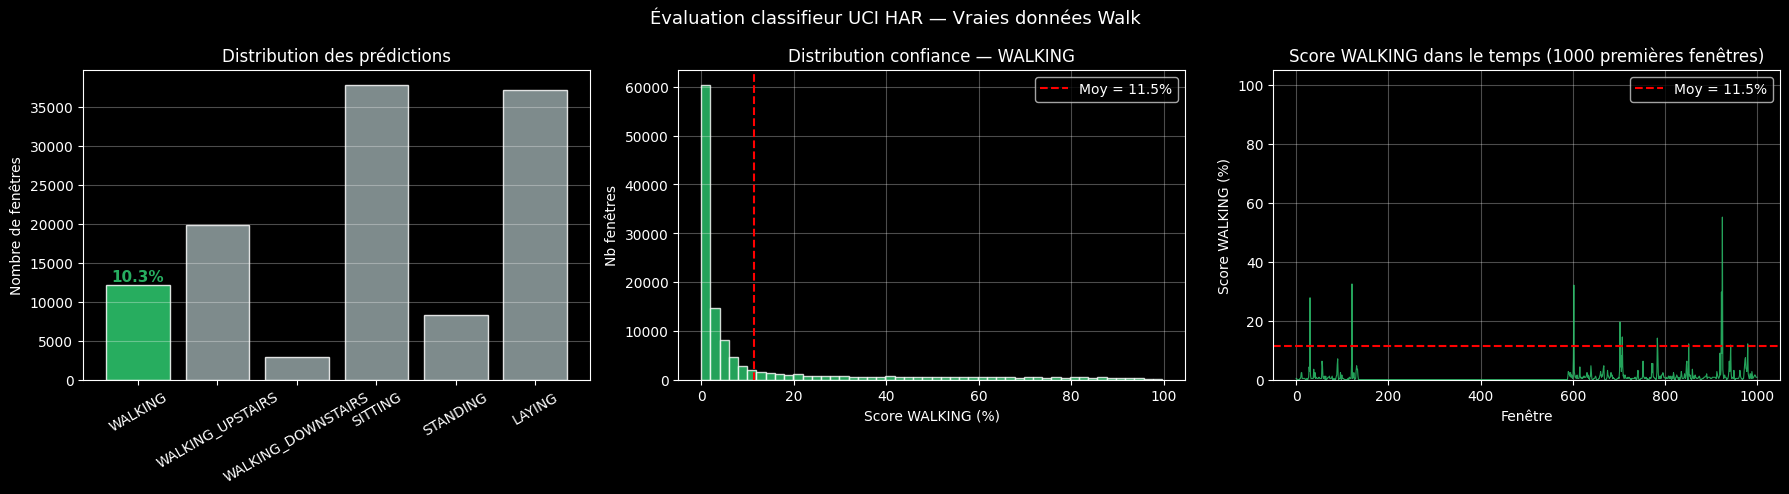


Graphique sauvegardé dans C:/Users/adril/Downloads/imu_classifier


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Évaluation classifieur UCI HAR — Vraies données Walk', fontsize=13)

# ── Figure 1 : Distribution des prédictions ───────────────────────
counts = [np.sum(all_preds == i) for i in range(6)]
colors_bar = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(6)]
axes[0].bar(CLASSIFIER_ACTIVITIES, counts, color=colors_bar, alpha=0.85, edgecolor='white')
axes[0].set_title('Distribution des prédictions')
axes[0].set_ylabel('Nombre de fenêtres')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)
axes[0].annotate(f'{walking_rate:.1f}%',
                 xy=(0, counts[0]), xytext=(0, counts[0]*1.05),
                 ha='center', fontsize=11, fontweight='bold', color='#27ae60')

# ── Figure 2 : Distribution de la confiance WALKING ───────────────
axes[1].hist(all_probs[:, WALKING_CLASS_IDX] * 100, bins=50,
             color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1].axvline(mean_conf_walk, color='red', linestyle='--',
                label=f'Moy = {mean_conf_walk:.1f}%')
axes[1].set_title('Distribution confiance — WALKING')
axes[1].set_xlabel('Score WALKING (%)')
axes[1].set_ylabel('Nb fenêtres')
axes[1].legend(); axes[1].grid(alpha=0.3)

# ── Figure 3 : Confiance WALKING dans le temps (1000 premiers) ────
n_show = min(1000, len(all_probs))
axes[2].plot(all_probs[:n_show, WALKING_CLASS_IDX] * 100,
             color='#2ecc71', alpha=0.8, linewidth=0.8)
axes[2].axhline(mean_conf_walk, color='red', linestyle='--',
                label=f'Moy = {mean_conf_walk:.1f}%')
axes[2].set_title(f'Score WALKING dans le temps ({n_show} premières fenêtres)')
axes[2].set_xlabel('Fenêtre'); axes[2].set_ylabel('Score WALKING (%)')
axes[2].set_ylim(0, 105)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'eval_walk_reelles.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nGraphique sauvegardé dans {MODEL_DIR}')

## 9. Sauvegarde du dataset walk adapté UCI HAR

On sauvegarde `X_norm` (N, 128, 9) et `X_raw` (N, 50, 3) dans le parquet final.
Ce sera utilisé ensuite pour évaluer les données **générées par le VAE**.

In [11]:
# Sauvegarder sous forme tabulaire :
# Chaque ligne = une fenêtre
# Colonnes : raw_acc_x_0..49, raw_acc_y_0..49, raw_acc_z_0..49
#            norm_ch0_0..127 ... norm_ch8_0..127

print('Sauvegarder le dataset walk adapté...')

# On sauvegarde en numpy (plus pratique pour le notebook VAE)
NUMPY_PATH = r"C:/Users/adril/Downloads/walk_ucihar_adapted.npz"

np.savez_compressed(
    NUMPY_PATH,
    X_norm=X_norm,    # (N, 128, 9) — format UCI HAR normalisé
    X_raw=X_raw,      # (N, 50, 3)  — format brut pour le VAE
    scaler_mean=scaler.mean_,
    scaler_std=scaler.scale_,
)

size_mb = os.path.getsize(NUMPY_PATH) / (1024**2)
print(f'Sauvegardé : {NUMPY_PATH}  ({size_mb:.1f} MB)')
print(f'  X_norm : {X_norm.shape}')
print(f'  X_raw  : {X_raw.shape}')
print()
print('=' * 55)
print('RÉCAPITULATIF FINAL')
print('=' * 55)
print(f'  Fenêtres walk extraites : {len(X_norm):,}')
print(f'  Taux WALKING (classif.) : {walking_rate:.2f}%')
print(f'  Confiance moy. WALKING  : {mean_conf_walk:.2f}%')
print(f'  Dataset UCI HAR sauvé   : {NUMPY_PATH}')
print(f'  Dataset walk brut       : {OUTPUT_PATH}')
print('=' * 55)
print()
print('→ Prochaine étape : générer des données Walk avec le VAE,')
print('  appliquer les mêmes transformations, et comparer les scores.')

Sauvegarder le dataset walk adapté...
Sauvegardé : C:/Users/adril/Downloads/walk_ucihar_adapted.npz  (364.4 MB)
  X_norm : (117945, 128, 9)
  X_raw  : (117945, 50, 3)

RÉCAPITULATIF FINAL
  Fenêtres walk extraites : 117,945
  Taux WALKING (classif.) : 10.25%
  Confiance moy. WALKING  : 11.46%
  Dataset UCI HAR sauvé   : C:/Users/adril/Downloads/walk_ucihar_adapted.npz
  Dataset walk brut       : C:/Users/adril/Downloads/walk_dataset.parquet

→ Prochaine étape : générer des données Walk avec le VAE,
  appliquer les mêmes transformations, et comparer les scores.
